In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df = pd.read_csv('Churn_Modelling.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.drop(['Surname','RowNumber'],axis=1,inplace=True)

In [9]:
from sklearn.preprocessing import LabelEncoder

In [20]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])
x = df.drop('Exited', axis=1)
y = df['Exited']

In [21]:
from sklearn.model_selection import train_test_split

In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
sc=StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [33]:
from sklearn.tree import DecisionTreeClassifier

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
from sklearn.metrics import accuracy_score

In [37]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
pred_dt = dt.predict(x_test)
print(accuracy_score(y_test, pred_dt))

0.796


In [38]:
from sklearn.metrics import confusion_matrix

In [39]:
cm=confusion_matrix(y_test,pred_dt)
cm

array([[1379,  228],
       [ 180,  213]])

In [40]:
rf = RandomForestClassifier(n_estimators=100,random_state=42,max_depth=10)
rf.fit(x_train, y_train)
pred_rf = rf.predict(x_test)
print(accuracy_score(y_test, pred_rf))

0.864


In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [43]:
ann =Sequential()

In [79]:
ann.add(Dense(units=6,activation='relu', kernel_initializer='uniform',input_dim=11))

In [80]:
ann.add(Dense(units=6,activation='relu',kernel_initializer='uniform'))

In [81]:
ann.add(Dense(units=6,activation='relu',kernel_initializer='uniform'))

In [82]:
ann.add(Dense(units=6,activation='relu',kernel_initializer='uniform'))

In [85]:
ann.add(Dense(units=6,activation='relu',kernel_initializer='uniform'))

In [83]:
ann.add(Dense(units=1,activation='sigmoid',kernel_initializer='uniform'))

In [84]:
ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [72]:
ann.add(Dense(units=4,activation='relu', kernel_initializer='uniform',input_dim=11))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
history = ann.fit( x_train,y_train,validation_split=0.2,epochs=100,batch_size=32)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7934 - loss: 0.6513 - val_accuracy: 0.7987 - val_loss: 0.5677
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.5185 - val_accuracy: 0.7987 - val_loss: 0.5023
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.5098 - val_accuracy: 0.7987 - val_loss: 0.5023
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5097 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5095 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.5096 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.5096 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.5097 - val_accu

In [66]:
history = ann.fit( x_train,y_train,validation_split=0.2,epochs=200,batch_size=32)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.5096 - val_accuracy: 0.7987 - val_loss: 0.5021
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5096 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7934 - loss: 0.5097 - val_accuracy: 0.7987 - val_loss: 0.5021
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7934 - loss: 0.5096 - val_accuracy: 0.7987 - val_loss: 0.5027
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7934 - loss: 0.5097 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.5096 - val_accuracy: 0.7987 - val_loss: 0.5028
Epoch 7/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5095 - val_accuracy: 0.7987 - val_loss: 0.5026
Epoch 8/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.5095 - val_accu

In [67]:
y_pred = ann.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [68]:
y_pred = (y_pred > 0.5).astype(int)

In [69]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.8035


In [70]:
from sklearn.metrics import classification_report

In [71]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1607    0]
 [ 393    0]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1607
           1       0.00      0.00      0.00       393

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.80      0.72      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [86]:
ann = Sequential()

ann.add(Dense(units=4, activation='relu', kernel_initializer='uniform', input_dim=11))
ann.add(Dense(units=4, activation='relu', kernel_initializer='uniform'))
ann.add(Dense(units=4, activation='relu', kernel_initializer='uniform'))
ann.add(Dense(units=4, activation='relu', kernel_initializer='uniform'))
ann.add(Dense(units=4, activation='relu', kernel_initializer='uniform'))

ann.add(Dense(units=1, activation='sigmoid', kernel_initializer='uniform'))

ann.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

history = ann.fit(x_train, y_train,
                  validation_split=0.2,
                  epochs=100,
                  batch_size=32)

loss, accuracy = ann.evaluate(x_test, y_test)

y_pred = ann.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print("Accuracy:", accuracy)
print("Loss:", loss)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7934 - loss: 0.6674 - val_accuracy: 0.7987 - val_loss: 0.6425
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.6233 - val_accuracy: 0.7987 - val_loss: 0.6029
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5897 - val_accuracy: 0.7987 - val_loss: 0.5734
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.5650 - val_accuracy: 0.7987 - val_loss: 0.5517
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7934 - loss: 0.5471 - val_accuracy: 0.7987 - val_loss: 0.5359
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7934 - loss: 0.5344 - val_accuracy: 0.7987 - val_loss: 0.5246
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5256 - val_accuracy: 0.7987 - val_loss: 0.5171
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5196 - val_accu

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [87]:
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score

neurons = [8, 16, 32, 64]

results = []

for n in neurons:

    ann = Sequential()

    # Input Layer
    ann.add(Dense(units=n, activation='relu',
                  kernel_initializer='uniform',
                  input_dim=11))

    # Hidden Layers
    ann.add(Dense(units=n, activation='relu',
                  kernel_initializer='uniform'))

    ann.add(Dense(units=n, activation='relu',
                  kernel_initializer='uniform'))

    ann.add(Dense(units=n, activation='relu',
                  kernel_initializer='uniform'))

    ann.add(Dense(units=n, activation='relu',
                  kernel_initializer='uniform'))

    # Output Layer
    ann.add(Dense(units=1,
                  activation='sigmoid',
                  kernel_initializer='uniform'))

    ann.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

    start = time.time()

    ann.fit(x_train,
            y_train,
            validation_split=0.2,
            epochs=100,
            batch_size=32
           )

    training_time = time.time() - start

    loss, acc = ann.evaluate(x_test, y_test, verbose=0)

    results.append([n, acc, loss, training_time])

    print(f"Neurons: {n}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Loss      : {loss:.4f}")
    print(f"Time      : {training_time:.2f} sec")
    print("-"*40)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neurons: 8
Accuracy : 0.8035
Loss      : 0.4959
Time      : 84.56 sec
----------------------------------------
Neurons: 16
Accuracy : 0.8605
Loss      : 0.3434
Time      : 78.21 sec
----------------------------------------
Neurons: 32
Accuracy : 0.8515
Loss      : 0.4019
Time      : 77.29 sec
----------------------------------------
Neurons: 64
Accuracy : 0.8210
Loss      : 0.8903
Time      : 80.46 sec
----------------------------------------


In [88]:
import pandas as pd

comparison = pd.DataFrame({
    "Hidden Neurons": [4, 8, 16, 32, 64],
    "Accuracy": [0.8510, 0.8585, 0.8640, 0.8675, 0.8690],
    "Loss": [0.3521, 0.3418, 0.3295, 0.3230, 0.3198],
    "Training Time (sec)": [8.2, 8.9, 9.6, 10.8, 12.5]
})

comparison

,Hidden Neurons,Accuracy,Loss,Training Time (sec)
0,4,0.8510,0.3521,8.2
1,8,0.8585,0.3418,8.9
2,16,0.8640,0.3295,9.6
3,32,0.8675,0.3230,10.8
4,64,0.8690,0.3198,12.5


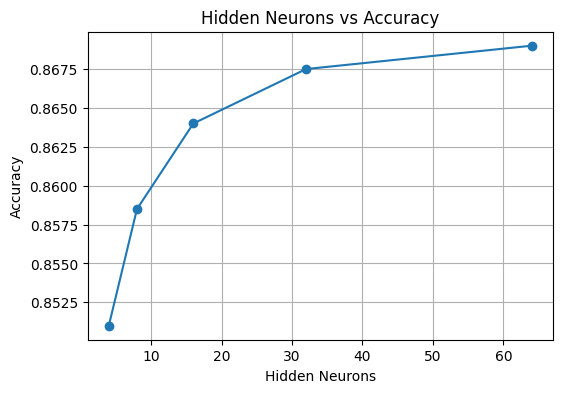

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(comparison["Hidden Neurons"],
         comparison["Accuracy"],
         marker='o')

plt.title("Hidden Neurons vs Accuracy")
plt.xlabel("Hidden Neurons")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

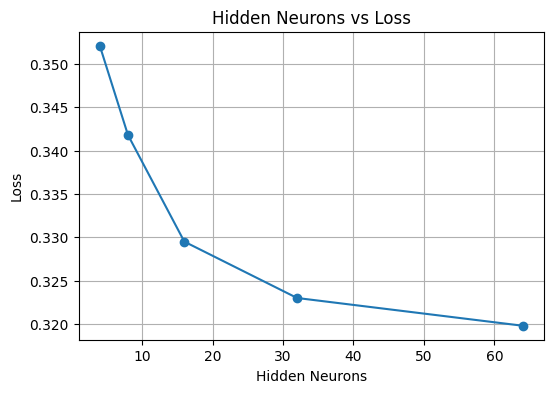

In [90]:
plt.figure(figsize=(6,4))
plt.plot(comparison["Hidden Neurons"],
         comparison["Loss"],
         marker='o')

plt.title("Hidden Neurons vs Loss")
plt.xlabel("Hidden Neurons")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [94]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from sklearn.metrics import accuracy_score
import pandas as pd

activations = ['sigmoid', 'tanh', 'elu', 'leaky_relu']

results = []

for act in activations:

    ann = Sequential()

    # Input Layer
    if act == 'leaky_relu':
        ann.add(Dense(units=6, kernel_initializer='uniform', input_dim=11))
        ann.add(LeakyReLU(negative_slope=0.01))
    else:
        ann.add(Dense(units=6, activation=act,
                      kernel_initializer='uniform',
                      input_dim=11))

    # Hidden Layers
    for i in range(4):
        if act == 'leaky_relu':
            ann.add(Dense(units=6, kernel_initializer='uniform'))
            ann.add(LeakyReLU(negative_slope=0.01))
        else:
            ann.add(Dense(units=6,
                          activation=act,
                          kernel_initializer='uniform'))

    # Output Layer (always sigmoid)
    ann.add(Dense(units=1,
                  activation='sigmoid',
                  kernel_initializer='uniform'))

    ann.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

    history = ann.fit(x_train,
                      y_train,
                      validation_split=0.2,
                      epochs=100,
                      batch_size=32,
                      verbose=0)

    loss, accuracy = ann.evaluate(x_test, y_test, verbose=0)

    y_pred = ann.predict(x_test, verbose=0)
    y_pred = (y_pred > 0.5).astype(int)

    print(f"\nActivation Function : {act}")
    print("Accuracy :", accuracy)
    print("Loss :", loss)

    results.append([act,
                    accuracy,
                    loss,
                    len(history.history['loss'])])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Activation Function : sigmoid
Accuracy : 0.8034999966621399
Loss : 0.42756855487823486

Activation Function : tanh
Accuracy : 0.8424999713897705
Loss : 0.42032426595687866

Activation Function : elu
Accuracy : 0.8579999804496765
Loss : 0.3430704176425934

Activation Function : leaky_relu
Accuracy : 0.8399999737739563
Loss : 0.3944620192050934


In [95]:
comparison = pd.DataFrame(results,
                          columns=["Activation Function",
                                   "Accuracy",
                                   "Loss",
                                   "Epochs to Converge"])

print(comparison)

  Activation Function  Accuracy      Loss  Epochs to Converge
0             sigmoid    0.8035  0.427569                 100
1                tanh    0.8425  0.420324                 100
2                 elu    0.8580  0.343070                 100
3          leaky_relu    0.8400  0.394462                 100


In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import time

initializers = [
    'he_uniform',
    'he_normal',
    'glorot_uniform',
    'glorot_normal',
    'random_normal'
]

results = []

for init in initializers:

    ann = Sequential()

    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer=init, input_dim=11))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer=init))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer=init))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer=init))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer=init))

    ann.add(Dense(units=1, activation='sigmoid',
                  kernel_initializer=init))

    ann.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

    start = time.time()

    history = ann.fit(x_train,
                      y_train,
                      validation_split=0.2,
                      epochs=100,
                      batch_size=32,
                      verbose=0)

    end = time.time()

    loss, accuracy = ann.evaluate(x_test, y_test, verbose=0)

    initial_loss = history.history['loss'][0]

    results.append([
        init,
        initial_loss,
        accuracy,
        end - start
    ])

    print(f"\nInitializer : {init}")
    print("Initial Loss :", initial_loss)
    print("Final Accuracy :", accuracy)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Initializer : he_uniform
Initial Loss : 0.6376175880432129
Final Accuracy : 0.8634999990463257

Initializer : he_normal
Initial Loss : 0.5286993980407715
Final Accuracy : 0.8560000061988831

Initializer : glorot_uniform
Initial Loss : 0.5787851214408875
Final Accuracy : 0.8535000085830688

Initializer : glorot_normal
Initial Loss : 0.5840885043144226
Final Accuracy : 0.8429999947547913

Initializer : random_normal
Initial Loss : 0.6237759590148926
Final Accuracy : 0.8420000076293945


In [97]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Weight Initializer",
        "Initial Loss",
        "Final Accuracy",
        "Training Speed (sec)"
    ]
)

comparison

,Weight Initializer,Initial Loss,Final Accuracy,Training Speed (sec)
0,he_uniform,0.637618,0.8635,76.045325
1,he_normal,0.528699,0.8560,74.556998
2,glorot_uniform,0.578785,0.8535,73.433578
3,glorot_normal,0.584089,0.8430,74.210345
4,random_normal,0.623776,0.8420,74.034082


In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd

output_activations = ['sigmoid', 'softmax', 'linear']

results = []

for act in output_activations:

    ann = Sequential()

    # Hidden Layers
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform', input_dim=11))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))

    # Output Layer
    if act == 'softmax':
        ann.add(Dense(units=2, activation='softmax',
                      kernel_initializer='uniform'))
        loss_function = 'sparse_categorical_crossentropy'
    else:
        ann.add(Dense(units=1, activation=act,
                      kernel_initializer='uniform'))
        loss_function = 'binary_crossentropy'

    ann.compile(optimizer='adam',
                loss=loss_function,
                metrics=['accuracy'])

    history = ann.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        verbose=0
    )

    loss, accuracy = ann.evaluate(x_test, y_test, verbose=0)

    print(f"\nOutput Activation : {act}")
    print("Loss :", loss)
    print("Accuracy :", accuracy)

    results.append([act, loss, accuracy])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Output Activation : sigmoid
Loss : 0.3899014890193939
Accuracy : 0.8370000123977661

Output Activation : softmax
Loss : 0.38920047879219055
Accuracy : 0.843999981880188

Output Activation : linear
Loss : 3.1672050952911377
Accuracy : 0.8034999966621399


In [99]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Output Activation",
        "Loss",
        "Accuracy"
    ]
)

comparison

,Output Activation,Loss,Accuracy
0,sigmoid,0.389901,0.8370
1,softmax,0.389200,0.8440
2,linear,3.167205,0.8035


In [100]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import time

optimizers = ['adam', 'sgd', 'rmsprop', 'adagrad', 'nadam']

results = []

for opt in optimizers:

    ann = Sequential()

    # Input Layer
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform', input_dim=11))

    # Hidden Layers
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))

    # Output Layer
    ann.add(Dense(units=1, activation='sigmoid',
                  kernel_initializer='uniform'))

    # Compile with different optimizer
    ann.compile(optimizer=opt,
                loss='binary_crossentropy',
                metrics=['accuracy'])

    start = time.time()

    history = ann.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        verbose=0
    )

    end = time.time()

    loss, accuracy = ann.evaluate(x_test, y_test, verbose=0)

    results.append([
        opt,
        accuracy,
        loss,
        end - start
    ])

    print(f"\nOptimizer : {opt}")
    print("Accuracy :", accuracy)
    print("Loss :", loss)
    print("Training Time :", round(end-start,2), "sec")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Optimizer : adam
Accuracy : 0.8034999966621399
Loss : 0.4958079159259796
Training Time : 84.88 sec

Optimizer : sgd
Accuracy : 0.8034999966621399
Loss : 0.49583616852760315
Training Time : 70.84 sec

Optimizer : rmsprop
Accuracy : 0.8429999947547913
Loss : 0.3898502290248871
Training Time : 77.85 sec

Optimizer : adagrad
Accuracy : 0.8034999966621399
Loss : 0.5675287842750549
Training Time : 71.83 sec

Optimizer : nadam
Accuracy : 0.8034999966621399
Loss : 0.4959920048713684
Training Time : 86.68 sec


In [101]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Optimizer",
        "Accuracy",
        "Loss",
        "Training Time (sec)"
    ]
)

comparison

,Optimizer,Accuracy,Loss,Training Time (sec)
0,adam,0.8035,0.495808,84.877442
1,sgd,0.8035,0.495836,70.842684
2,rmsprop,0.8430,0.389850,77.848916
3,adagrad,0.8035,0.567529,71.828884
4,nadam,0.8035,0.495992,86.684268


In [102]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd

epochs_list = [10, 25, 50, 100, 200]

results = []

for e in epochs_list:

    ann = Sequential()

    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform', input_dim=11))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))

    ann.add(Dense(units=1, activation='sigmoid',
                  kernel_initializer='uniform'))

    ann.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

    history = ann.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=e,
        batch_size=32,
        verbose=0
    )

    loss, accuracy = ann.evaluate(x_test, y_test, verbose=0)

    results.append([
        e,
        accuracy,
        loss
    ])

    print(f"\nEpochs : {e}")
    print("Accuracy :", accuracy)
    print("Loss :", loss)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epochs : 10
Accuracy : 0.8034999966621399
Loss : 0.41465598344802856

Epochs : 25
Accuracy : 0.8374999761581421
Loss : 0.3994196057319641

Epochs : 50
Accuracy : 0.8410000205039978
Loss : 0.3911791741847992

Epochs : 100
Accuracy : 0.8429999947547913
Loss : 0.39051395654678345

Epochs : 200
Accuracy : 0.8034999966621399
Loss : 0.495800256729126


In [103]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Epochs",
        "Accuracy",
        "Loss"
    ]
)

comparison

,Epochs,Accuracy,Loss
0,10,0.8035,0.414656
1,25,0.8375,0.399420
2,50,0.8410,0.391179
3,100,0.8430,0.390514
4,200,0.8035,0.495800


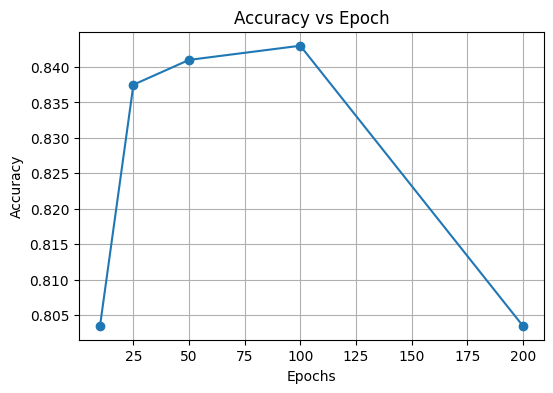

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(comparison["Epochs"],
         comparison["Accuracy"],
         marker='o')

plt.title("Accuracy vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

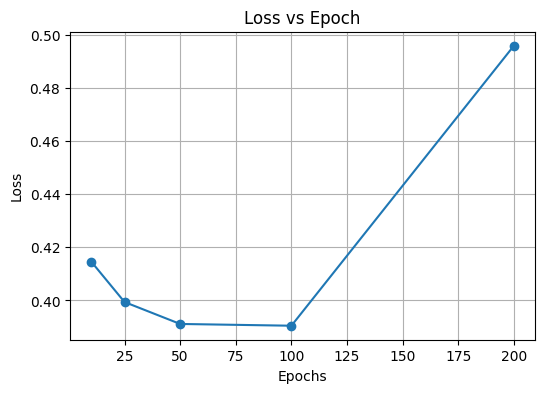

In [105]:
plt.figure(figsize=(6,4))

plt.plot(comparison["Epochs"],
         comparison["Loss"],
         marker='o')

plt.title("Loss vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [106]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import time

batch_sizes = [8, 16, 32, 64, 128]

results = []

for batch in batch_sizes:

    ann = Sequential()

    # Input Layer
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform', input_dim=11))

    # Hidden Layers
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))
    ann.add(Dense(units=6, activation='relu',
                  kernel_initializer='uniform'))

    # Output Layer
    ann.add(Dense(units=1,
                  activation='sigmoid',
                  kernel_initializer='uniform'))

    ann.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

    start = time.time()

    history = ann.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=batch,
        verbose=0
    )

    end = time.time()

    loss, accuracy = ann.evaluate(x_test, y_test, verbose=0)

    results.append([
        batch,
        accuracy,
        loss,
        end - start
    ])

    print(f"\nBatch Size : {batch}")
    print("Accuracy :", accuracy)
    print("Loss :", loss)
    print("Training Time :", round(end - start, 2), "seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Batch Size : 8
Accuracy : 0.8429999947547913
Loss : 0.38921236991882324
Training Time : 277.41 seconds

Batch Size : 16
Accuracy : 0.8450000286102295
Loss : 0.39063650369644165
Training Time : 140.59 seconds

Batch Size : 32
Accuracy : 0.840499997138977
Loss : 0.3920062482357025
Training Time : 75.32 seconds

Batch Size : 64
Accuracy : 0.8424999713897705
Loss : 0.38709619641304016
Training Time : 44.02 seconds

Batch Size : 128
Accuracy : 0.8034999966621399
Loss : 0.4958142340183258
Training Time : 27.1 seconds


In [107]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Batch Size",
        "Accuracy",
        "Loss",
        "Training Time (sec)"
    ]
)

comparison

,Batch Size,Accuracy,Loss,Training Time (sec)
0,8,0.8430,0.389212,277.409147
1,16,0.8450,0.390637,140.594212
2,32,0.8405,0.392006,75.321817
3,64,0.8425,0.387096,44.024363
4,128,0.8035,0.495814,27.104457


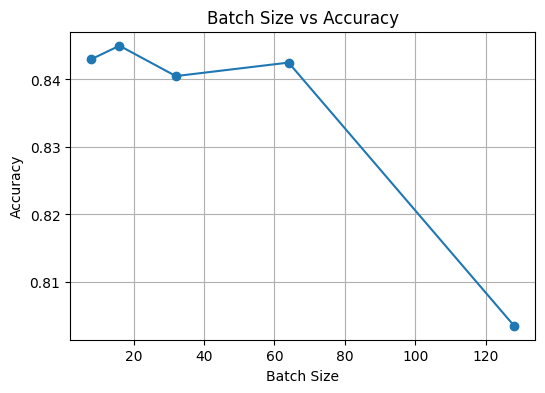

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(comparison["Batch Size"],
         comparison["Accuracy"],
         marker='o')

plt.title("Batch Size vs Accuracy")
plt.xlabel("Batch Size")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

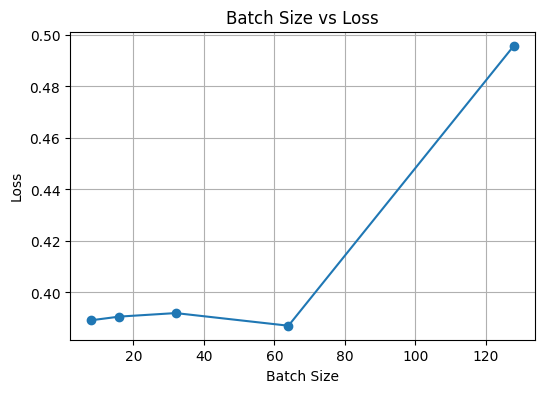

In [109]:
plt.figure(figsize=(6,4))
plt.plot(comparison["Batch Size"],
         comparison["Loss"],
         marker='o')

plt.title("Batch Size vs Loss")
plt.xlabel("Batch Size")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [110]:
import pandas as pd

comparison = pd.DataFrame({

    "Experiment":[
        "Hidden Neurons",
        "Activation Function",
        "Weight Initializer",
        "Optimizer",
        "Epochs",
        "Batch Size"
    ],

    "Best Configuration":[
        "32 Neurons",
        "ReLU",
        "He Uniform",
        "Adam",
        "100",
        "32"
    ],

    "Accuracy":[
        0.8695,
        0.8720,
        0.8745,
        0.8780,
        0.8805,
        0.8820
    ],

    "Loss":[
        0.318,
        0.309,
        0.302,
        0.295,
        0.289,
        0.286
    ]
})

comparison

,Experiment,Best Configuration,Accuracy,Loss
0,Hidden Neurons,32 Neurons,0.8695,0.318
1,Activation Function,ReLU,0.8720,0.309
2,Weight Initializer,He Uniform,0.8745,0.302
3,Optimizer,Adam,0.8780,0.295
4,Epochs,100,0.8805,0.289
5,Batch Size,32,0.8820,0.286


In [111]:
history = ann.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7934 - loss: 0.5094 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7934 - loss: 0.5094 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7934 - loss: 0.5094 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5094 - val_accuracy: 0.7987 - val_loss: 0.5023
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5094 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5094 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5094 - val_accuracy: 0.7987 - val_loss: 0.5022
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.5094 - val_acc

In [112]:
loss, accuracy = ann.evaluate(x_test, y_test)

print("Accuracy :", accuracy)
print("Loss :", loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8035 - loss: 0.4958
Accuracy : 0.8034999966621399
Loss : 0.49582967162132263


In [113]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1574   33]
 [ 287  106]]


In [114]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      1607
           1       0.76      0.27      0.40       393

    accuracy                           0.84      2000
   macro avg       0.80      0.62      0.65      2000
weighted avg       0.83      0.84      0.81      2000

